# COMP4318/5318 Assignment 2: Image Classification

### Group number: 153
SID1: 540430668
SID2: 540776016
SID3: 520197321
SID4: ... 

This template notebook includes code to load the  dataset and a skeleton for the main sections that should be included in the notebook. Please stick to this struture for your submitted notebook.

Please focus on making your code clear, with appropriate variable names and whitespace. Include comments and markdown text to aid the readability of your code where relevant. See the specification and marking criteria in the associated specification to guide you when completing your implementation.

## Setup and dependencies
Please use this section to list and set up all your required libraries/dependencies and your plotting environment. 

In [ ]:
import os
# Suppress TensorFlow C++ INFO/WARNING (Metal device, NUMA, etc.); must run before importing tensorflow.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import time
import pandas as pd

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

from pathlib import Path

import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV, ParameterGrid
from sklearn.preprocessing import StandardScaler

# Try to use GPU-accelerated LogisticRegression from CuML, fallback to sklearn
USE_CUML = False
try:
    from cuml.linear_model import LogisticRegression
    USE_CUML = True
    print("GPU enabled for LogisticRegression using CuML")
except ImportError:
    from sklearn.linear_model import LogisticRegression
    print("GPU not available, using CPU for LogisticRegression")

from scikeras.wrappers import KerasClassifier

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120
RANDOM_STATE = 5318

processed_dir = Path('processed')
output_dir = Path('output')
processed_dir.mkdir(exist_ok=True)
output_dir.mkdir(exist_ok=True)

Using GPU-accelerated LogisticRegression from CuML


In [95]:
# GPU Configuration and Verification
print("TensorFlow version:", tf.__version__)

# Check available GPUs
gpus = tf.config.list_physical_devices('GPU')
print(f"Number of GPUs available: {len(gpus)}")

if gpus:
    for gpu in gpus:
        print(f"  GPU: {gpu}")
    
    # Enable memory growth to avoid OOM errors
    for gpu in gpus:
        tf.config.experimental.set_memory_growth(gpu, True)
    print("GPU memory growth enabled.")
else:
    print("No GPU detected, using CPU instead.")

TensorFlow version: 2.17.0
Number of GPUs available: 1
  GPU: PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')
GPU memory growth enabled.


## 1. Data loading, exploration, and preprocessing


Code to load the dataset is provided in the following cell. Please proceed with your data exploration and preprocessing in the remainder of this section.

In [9]:
# Load the dataset training and test sets as numpy arrays
# assuming Assignment2Data folder is present in the same directory 
# as the notebook
X_train = np.load('Assignment2Data/X_train.npy')
y_train = np.load('Assignment2Data/y_train.npy')
X_test = np.load('Assignment2Data/X_test.npy')
y_test = np.load('Assignment2Data/y_test.npy')

### Dataset overview
Start by checking dataset size, datatype, and label coverage before plotting.

In [10]:
print(f'X_train shape: {X_train.shape}, dtype: {X_train.dtype}')
print(f'y_train shape: {y_train.shape}, dtype: {y_train.dtype}')
print(f'X_test shape: {X_test.shape}, dtype: {X_test.dtype}')
print(f'y_test shape: {y_test.shape}, dtype: {y_test.dtype}')
print(f'Pixel range in training data: [{X_train.min()}, {X_train.max()}]')
print(f'Unique class labels: {np.unique(y_train)}') 

X_train shape: (32000, 28, 28, 3), dtype: uint8
y_train shape: (32000,), dtype: uint8
X_test shape: (8000, 28, 28, 3), dtype: uint8
y_test shape: (8000,), dtype: uint8
Pixel range in training data: [0, 255]
Unique class labels: [0 1 2 3 4 5 6 7 8]


### Class distribution
This bar chart checks whether the classes are balanced in the training split.

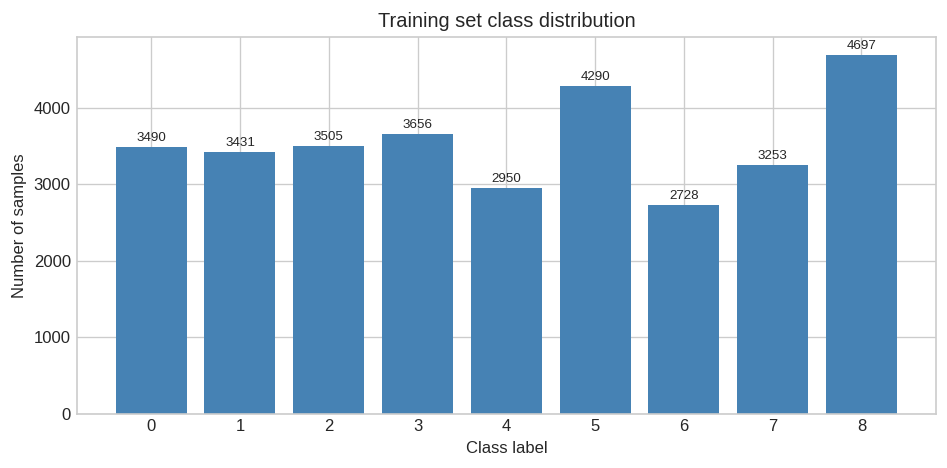

In [11]:
class_ids, class_counts = np.unique(y_train, return_counts=True)

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(class_ids.astype(str), class_counts, color='steelblue')
ax.set_title('Training set class distribution')
ax.set_xlabel('Class label')
ax.set_ylabel('Number of samples')
for idx, count in enumerate(class_counts):
    ax.text(idx, count + 40, str(count), ha='center', va='bottom', fontsize=8)
fig.tight_layout()
fig.savefig(output_dir / 'class_distribution.png', bbox_inches='tight')
plt.show()

### Sample images from each class
Display a few examples per class to inspect intra-class variation and class similarity.

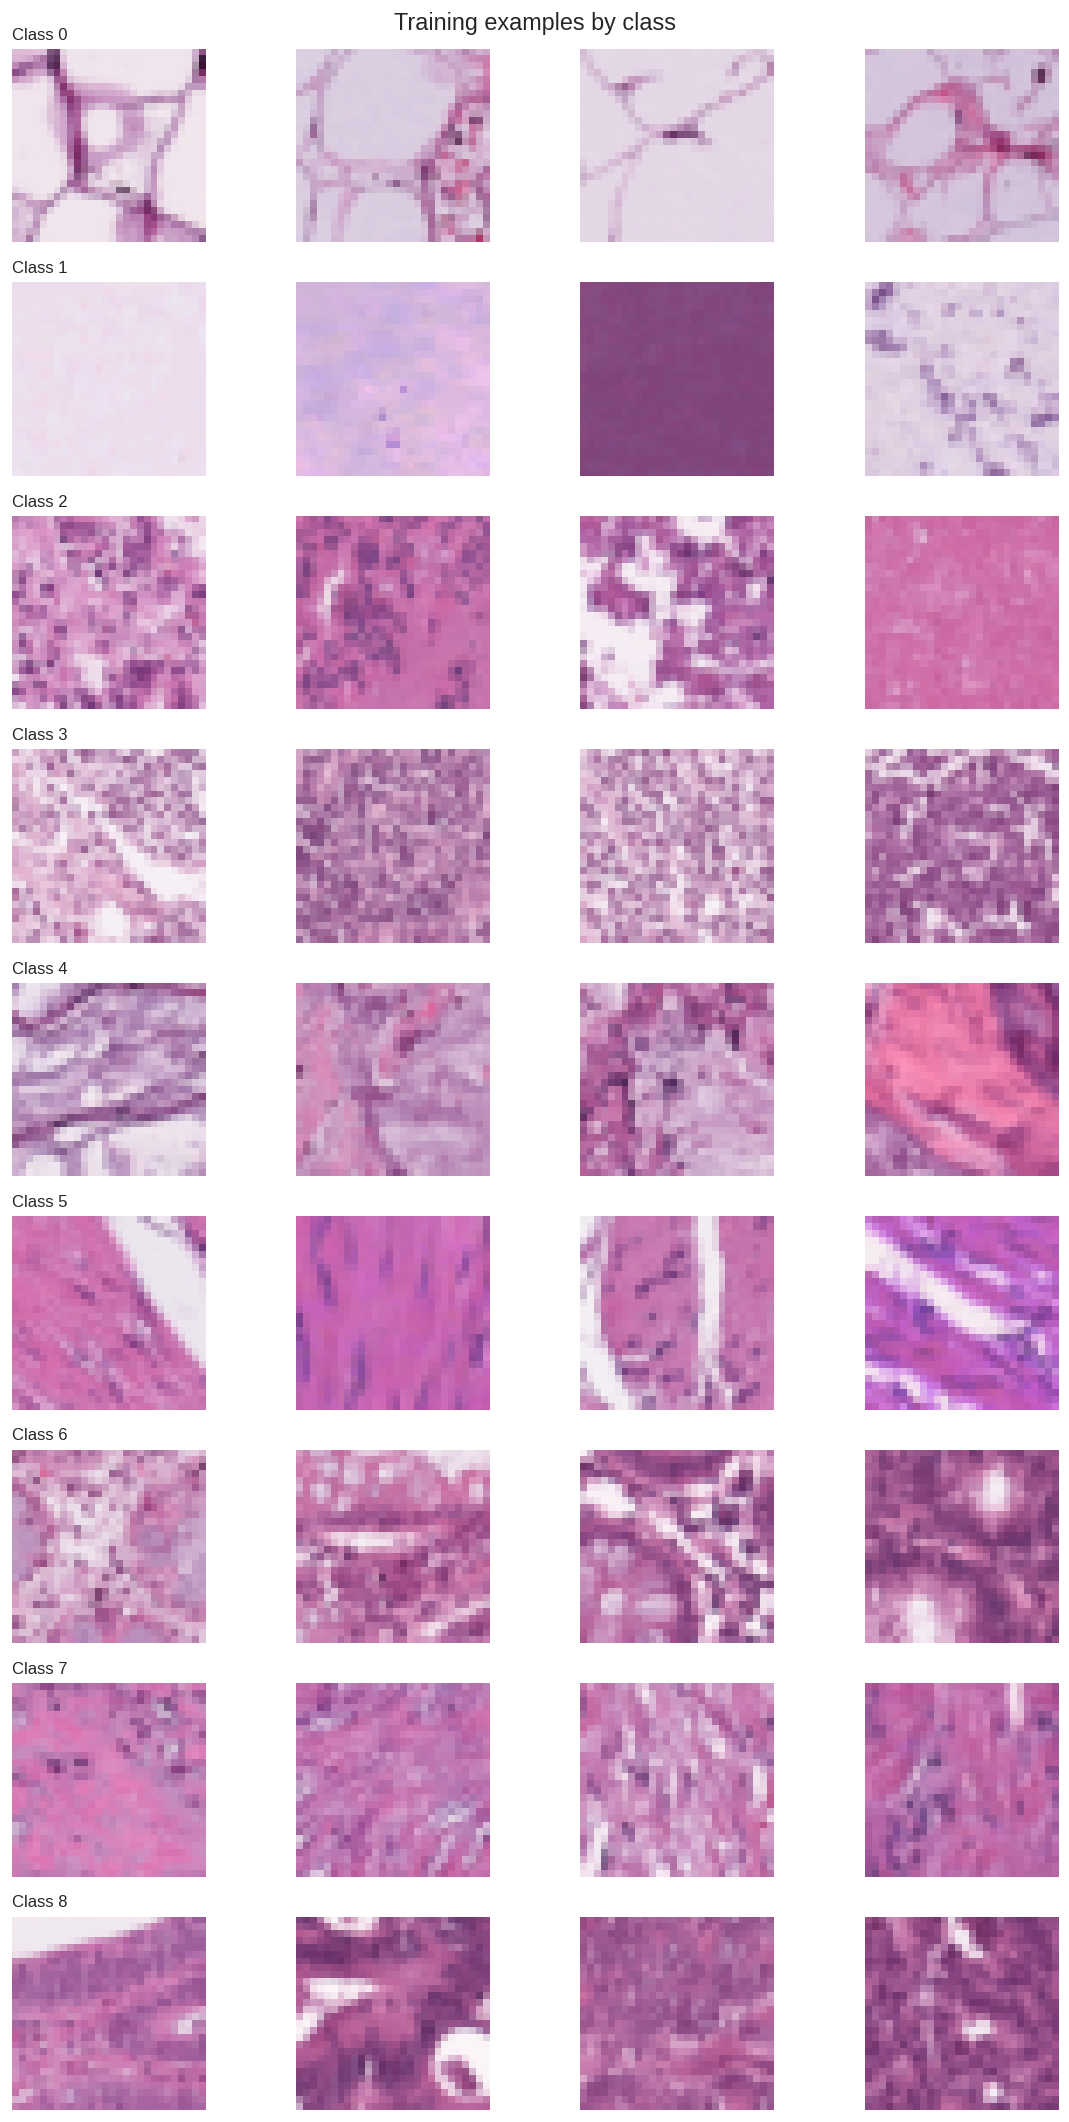

In [12]:
samples_per_class = 4
fig, axes = plt.subplots(len(class_ids), samples_per_class, figsize=(10, 18))

for row, class_id in enumerate(class_ids):
    sample_indices = np.where(y_train == class_id)[0][:samples_per_class]
    for col, sample_idx in enumerate(sample_indices):
        axes[row, col].imshow(X_train[sample_idx])
        axes[row, col].axis('off')
        if col == 0:
            axes[row, col].set_title(f'Class {class_id}', loc='left', fontsize=10)

fig.suptitle('Training examples by class', fontsize=14)
fig.tight_layout()
fig.savefig(output_dir / 'sample_images_by_class.png', bbox_inches='tight')
plt.show()

### Pixel intensity distribution
Plotting the raw pixel values helps justify scaling images to the [0, 1] range.

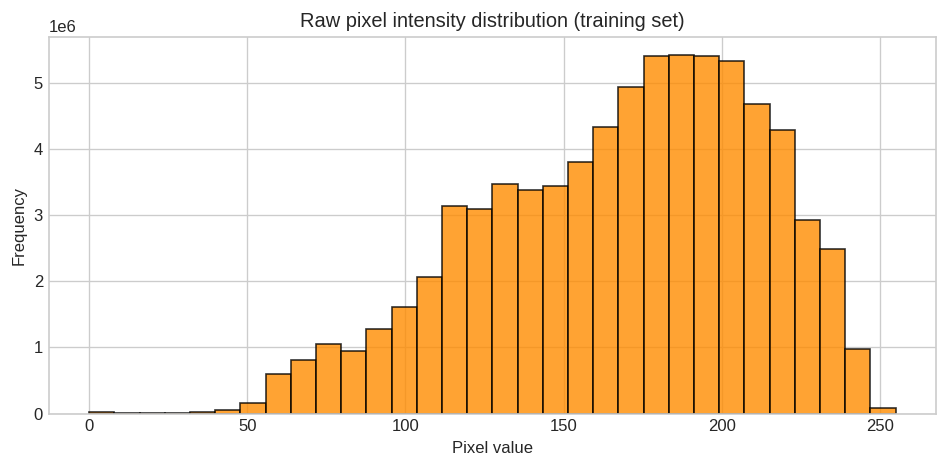

In [13]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(X_train.reshape(-1), bins=32, color='darkorange', edgecolor='black', alpha=0.8)
ax.set_title('Raw pixel intensity distribution (training set)')
ax.set_xlabel('Pixel value')
ax.set_ylabel('Frequency')
fig.tight_layout()
fig.savefig(output_dir / 'pixel_distribution.png', bbox_inches='tight')
plt.show()

### Preprocessing
The minimal preprocessing used here is image normalisation to float32 values in [0, 1], followed by a stratified train/validation split and a flattened copy for non-CNN models.

In [87]:
X_train_norm = X_train.astype(np.float32) / 255.0
X_test_norm = X_test.astype(np.float32) / 255.0

X_train_full_flat = X_train_norm.reshape(len(X_train_norm), -1)
X_test_full_flat = X_test_norm.reshape(len(X_test_norm), -1)

X_train_img, X_val_img, y_train_split, y_val = train_test_split(
    X_train_norm,
    y_train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y_train
)

X_train_flat = X_train_img.reshape(X_train_img.shape[0], -1)
X_val_flat = X_val_img.reshape(X_val_img.shape[0], -1)
X_test_flat = X_test_norm.reshape(X_test_norm.shape[0], -1)

np.save(processed_dir / 'X_train_img.npy', X_train_img)
np.save(processed_dir / 'X_val_img.npy', X_val_img)
np.save(processed_dir / 'X_test_img.npy', X_test_norm)
np.save(processed_dir / 'X_train_flat.npy', X_train_flat)
np.save(processed_dir / 'X_val_flat.npy', X_val_flat)
np.save(processed_dir / 'X_test_flat.npy', X_test_flat)
np.save(processed_dir / 'y_train.npy', y_train_split)
np.save(processed_dir / 'y_val.npy', y_val)
np.save(processed_dir / 'y_test.npy', y_test)

print('Saved processed arrays to:', processed_dir.resolve())
print(f'X_train_img shape: {X_train_img.shape}')
print(f'X_val_img shape: {X_val_img.shape}')
print(f'X_test_img shape: {X_test_norm.shape}')
print(f'X_train_flat shape: {X_train_flat.shape}')

Saved processed arrays to: /workspaces/COMP5318-Assignment-2/processed
X_train_img shape: (25600, 28, 28, 3)
X_val_img shape: (6400, 28, 28, 3)
X_test_img shape: (8000, 28, 28, 3)
X_train_flat shape: (25600, 2352)


### Examples of preprocessed data
The figure below compares raw and normalised images. The normalised images look visually similar, but their datatype and numeric range are now more suitable for model training.

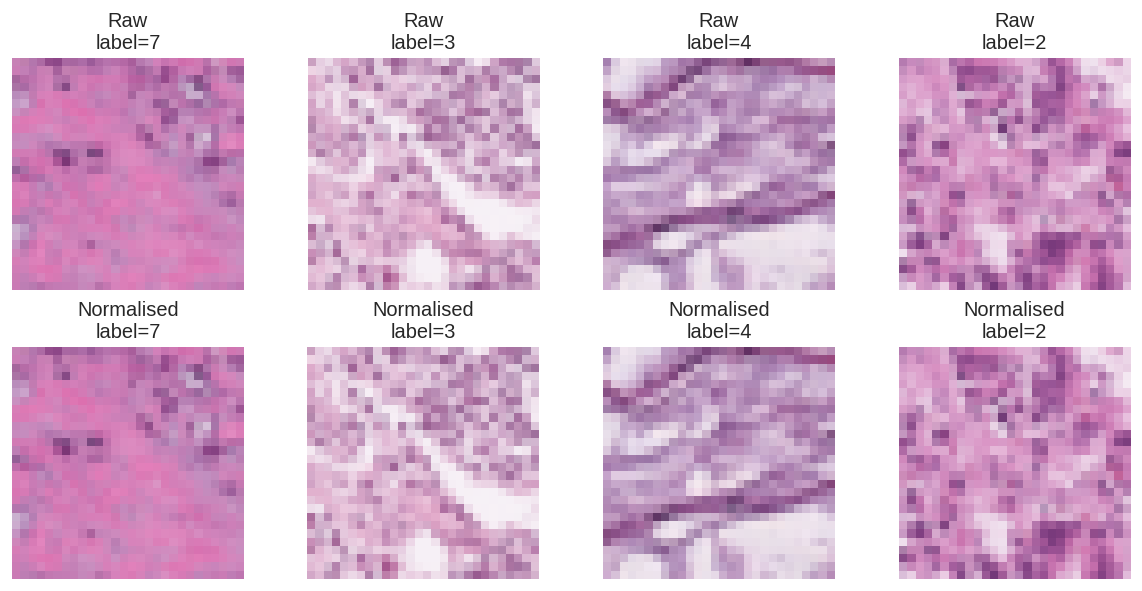

Normalised training range: [0.000, 1.000]
Flattened feature count per image: 2352


In [15]:
comparison_indices = [0, 1, 2, 3]
fig, axes = plt.subplots(2, len(comparison_indices), figsize=(10, 5))

for col, sample_idx in enumerate(comparison_indices):
    axes[0, col].imshow(X_train[sample_idx])
    axes[0, col].set_title(f'Raw\nlabel={y_train[sample_idx]}')
    axes[0, col].axis('off')

    axes[1, col].imshow(X_train_norm[sample_idx])
    axes[1, col].set_title(f'Normalised\nlabel={y_train[sample_idx]}')
    axes[1, col].axis('off')

fig.tight_layout()
fig.savefig(output_dir / 'preprocessing_comparison.png', bbox_inches='tight')
plt.show()

print(f'Normalised training range: [{X_train_norm.min():.3f}, {X_train_norm.max():.3f}]')
print(f'Flattened feature count per image: {X_train_flat.shape[1]}')

## 2. Algorithm design and setup

### Logistic Regression (Algorithm of choice from first six weeks of course)

In [96]:
# logistic Regression model and evaluation functions

# standardize the flattened features to achieve better performance with logistic regression
flat_scaler = StandardScaler()
X_train_full_flat_scaled = flat_scaler.fit_transform(X_train_full_flat)
X_test_full_flat_scaled  = flat_scaler.transform(X_test_full_flat)
X_train_flat_scaled = flat_scaler.transform(X_train_flat)
X_val_flat_scaled = flat_scaler.transform(X_val_flat)

# build a logistic regression model for flattened image vectors.
def build_logistic_regression(C=1.0, solver='lbfgs', class_weight=None):
    kwargs = {
        'C': C,
        'max_iter': 5000,
    }
    
    # GPU-optimized parameters for CuML's qn solver
    if USE_CUML:
        kwargs['solver'] = 'qn'
        kwargs['penalty'] = 'l2'
        kwargs['tol'] = 1e-3
    else:
        kwargs['solver'] = solver
        kwargs['class_weight'] = class_weight
        kwargs['random_state'] = RANDOM_STATE
    
    return LogisticRegression(**kwargs)


def evaluate_predictions(y_true, y_pred):
    return {
        'accuracy': accuracy_score(y_true, y_pred),
        'macro_f1': f1_score(y_true, y_pred, average='macro'),
        'weighted_f1': f1_score(y_true, y_pred, average='weighted'),
    }

### Fully connected neural network
In this architecture, a series of hidden dense layers with ReLU activation are utilized to extract non-linear representations, followed by dropout regularization to improve generalization. Unlike CNNs, MLPs cannot directly process spatial dimensions; therefore, the 28×28×3 PathMNIST images are flattened into a 1D vector, resulting in an input shape of (2352,). The final output layer consists of 9 neurons, outputting the probability distribution for the 9 disease categories.

In [17]:
keras.backend.clear_session() 
tf.random.set_seed(RANDOM_STATE) 

num_classes = len(np.unique(y_train_split))

def build_mlp_model(
    n_hidden_layers=2, 
    n_hidden_neurons=256,
    activation_function="relu", 
    dropout_rate=0.3,
    input_shape=None
):
    model = keras.models.Sequential()
    # Automatically obtain feature dimensions
    model.add(keras.layers.Input(shape=input_shape)) 
    
    for layer in range(n_hidden_layers):
        model.add(keras.layers.Dense(n_hidden_neurons, activation=activation_function))
        model.add(keras.layers.Dropout(dropout_rate))
        
    model.add(keras.layers.Dense(num_classes, activation="softmax"))
    return model


mlp_classifier = KerasClassifier(
    model=build_mlp_model,
    n_hidden_layers=2,
    n_hidden_neurons=256,
    activation_function="relu",
    dropout_rate=0.3,
    input_shape=(X_train_flat.shape[1],),
    
    loss="sparse_categorical_crossentropy",
    optimizer="adam",
    optimizer__learning_rate=0.001,
    metrics=["accuracy"],
    
    epochs=20,
    batch_size=64,
    verbose=0
)

mlp_model_instance = build_mlp_model(input_shape=(X_train_flat.shape[1],))
mlp_model_instance.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 256)               602368    
                                                                 
 dropout (Dropout)           (None, 256)               0         
                                                                 
 dense_1 (Dense)             (None, 256)               65792     
                                                                 
 dropout_1 (Dropout)         (None, 256)               0         
                                                                 
 dense_2 (Dense)             (None, 9)                 2313      
                                                                 
Total params: 670473 (2.56 MB)
Trainable params: 670473 (2.56 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


I0000 00:00:1777895231.788639    4965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1777895231.788782    4965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1777895231.788801    4965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1777895231.935317    4965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:00:1777895231.935361    4965 cuda_executor.cc:1001] could not open file to read NUMA node: /sys/bus/pci/devices/0000:01:00.0/numa_node
Your kernel may have been built without NUMA support.
I0000 00:0

### Convolutional neural network
In this CNN, two convolutional layers are used to extract local image features, followed by max pooling to reduce the spatial dimensions, and finally a dense layer for classification. Since PathMNIST consists of 28×28 color images, the input shape is (28, 28, 3). The output layer has 9 neurons, corresponding to the 9 categories.

In [78]:
num_classes = len(np.unique(y_train_split))
input_shape = X_train_img.shape[1:]

def build_cnn_model(
    conv_filters=32,
    dense_units=128,
    dropout_rate=0.3,
    learning_rate=0.001
):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(conv_filters, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Conv2D(conv_filters * 2, kernel_size=(3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D(pool_size=(2, 2)),

        layers.Flatten(),
        layers.Dense(dense_units, activation='relu'),
        layers.Dropout(dropout_rate),
        layers.Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model


cnn_model = build_cnn_model()
cnn_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 28, 28, 32)        896       
                                                                 
 max_pooling2d (MaxPooling2  (None, 14, 14, 32)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 14, 14, 64)        18496     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 7, 7, 64)          0         
 g2D)                                                            
                                                                 
 flatten (Flatten)           (None, 3136)              0         
                                                                 
 dense_3 (Dense)             (None, 128)              

## 3. Hyperparameter tuning

### Logistic Regression (Algorithm of choice from first six weeks of course)

#### Acceleration Options for Logistic Regression:
1. **GPU Acceleration (CuML)**: Uses NVIDIA GPU for ~5-10x speedup
2. **CPU Parallelization**: Uses all CPU cores for ~2-4x speedup  
3. **Reduced Search Space**: Fewer hyperparameter combinations


Starting logistic regression tuning over 11 combinations...
Using GPU acceleration: True
GPU acceleration enabled
[1/11] Training with {'C': 1e-05}...
    done: acc=0.4520, macro_f1=0.3538, fit=0.34s, predict=0.00s
[2/11] Training with {'C': 5e-05}...
    done: acc=0.5080, macro_f1=0.4345, fit=0.60s, predict=0.00s
[3/11] Training with {'C': 0.0001}...
    done: acc=0.5203, macro_f1=0.4574, fit=0.82s, predict=0.00s
[4/11] Training with {'C': 0.0005}...
    done: acc=0.5080, macro_f1=0.4674, fit=1.07s, predict=0.00s
[5/11] Training with {'C': 0.001}...
    done: acc=0.5031, macro_f1=0.4704, fit=1.40s, predict=0.00s
[6/11] Training with {'C': 0.005}...
    done: acc=0.4878, macro_f1=0.4647, fit=1.56s, predict=0.00s
[7/11] Training with {'C': 0.01}...
    done: acc=0.4820, macro_f1=0.4613, fit=1.60s, predict=0.00s
[8/11] Training with {'C': 0.05}...
    done: acc=0.4656, macro_f1=0.4501, fit=1.37s, predict=0.00s
[9/11] Training with {'C': 0.1}...
    done: acc=0.4647, macro_f1=0.4498, fit=

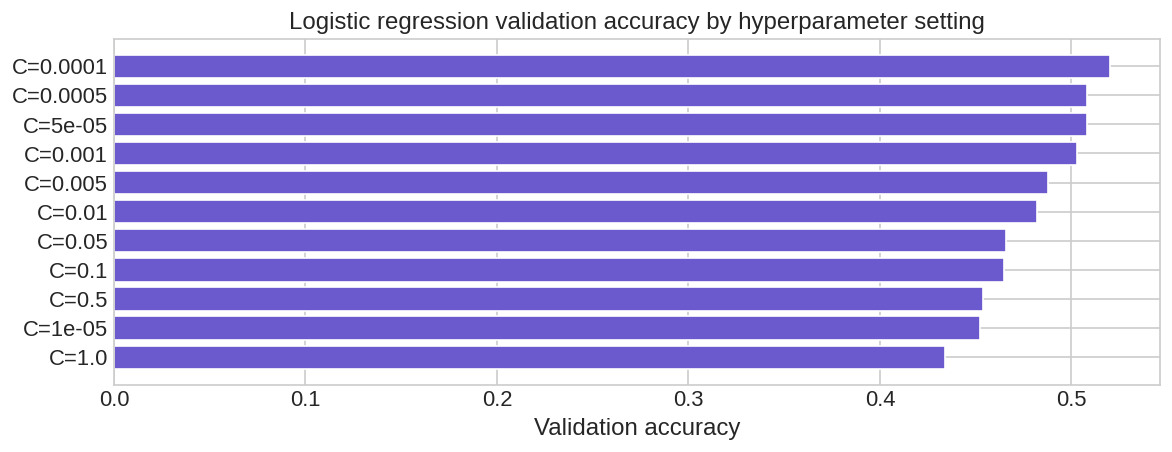

,C,accuracy,macro_f1,weighted_f1,fit_time_sec,predict_time_sec
0,0.00010,0.520312,0.457447,0.475047,0.823857,0.001019
1,0.00050,0.507969,0.467386,0.481055,1.067527,0.001515
2,0.00005,0.507969,0.434472,0.453118,0.603308,0.001075
3,0.00100,0.503125,0.470449,0.482397,1.401607,0.001345
4,0.00500,0.487812,0.464690,0.474741,1.564036,0.003072
5,0.01000,0.482031,0.461251,0.470922,1.595952,0.001385
6,0.05000,0.465625,0.450065,0.458829,1.371975,0.001433
7,0.10000,0.464687,0.449761,0.458221,1.482945,0.001653
8,0.50000,0.453594,0.438587,0.447755,1.694031,0.000848
9,0.00001,0.452031,0.353829,0.369517,0.337119,0.001780


In [98]:
lr_param_grid = list(ParameterGrid({
    'C': [1e-5, 5e-5, 1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1, 5e-1, 1],
}))

print(f'Starting logistic regression tuning over {len(lr_param_grid)} combinations...')
print(f'Using GPU acceleration: {USE_CUML}')
tuning_start = time.perf_counter()

# detect GPU for acceleration, fallback to CPU if not available
try:
    import cupy as cp
    
    # Convert pre-scaled data to GPU (scaling already done by flat_scaler)
    X_train_gpu = cp.asarray(X_train_flat_scaled)
    y_train_gpu = cp.asarray(y_train_split)
    X_val_gpu = cp.asarray(X_val_flat_scaled)
    y_val_gpu = cp.asarray(y_val)
    use_gpu = True
    print("GPU acceleration enabled")
except (ImportError, Exception) as e:
    use_gpu = False
    print(f"GPU acceleration not available: {type(e).__name__}")
    # Fallback to CPU with pre-scaled data
    X_train_gpu = X_train_flat_scaled
    y_train_gpu = y_train_split
    X_val_gpu = X_val_flat_scaled
    y_val_gpu = y_val

lr_results = []
for i, params in enumerate(lr_param_grid, start=1):
    print(f'[{i}/{len(lr_param_grid)}] Training with {params}...', flush=True)
    model = build_logistic_regression(**params)
    fit_start = time.perf_counter()
    model.fit(X_train_gpu, y_train_gpu)
    fit_time = time.perf_counter() - fit_start

    predict_start = time.perf_counter()
    val_pred = model.predict(X_val_gpu)
    if use_gpu:
        val_pred = cp.asnumpy(val_pred)
    predict_time = time.perf_counter() - predict_start

    metrics = evaluate_predictions(y_val, val_pred)
    lr_results.append({
        **params,
        **metrics,
        'fit_time_sec': fit_time,
        'predict_time_sec': predict_time,
    })

    print(
        f'    done: acc={metrics["accuracy"]:.4f}, macro_f1={metrics["macro_f1"]:.4f}, '
        f'fit={fit_time:.2f}s, predict={predict_time:.2f}s',
        flush=True,
    )

lr_results_df = pd.DataFrame(lr_results).sort_values(
    ['accuracy', 'macro_f1', 'fit_time_sec'],
    ascending=[False, False, True],
).reset_index(drop=True)
best_lr_params = {
    'C': lr_results_df.loc[0, 'C'],
}

print(f'Logistic regression tuning finished in {(time.perf_counter() - tuning_start) / 60:.2f} mins')
print('Logistic regression tuning results:')
print(lr_results_df.to_string(index=False))
print(f'Best logistic regression parameters: {best_lr_params}')

fig, ax = plt.subplots(figsize=(10, 4))
bar_labels = [f"C={row.C}" for row in lr_results_df.itertuples()]
ax.barh(bar_labels, lr_results_df['accuracy'], color='slateblue')
ax.set_xlabel('Validation accuracy')
ax.set_title('Logistic regression validation accuracy by hyperparameter setting')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

lr_results_df

### Fully connected neural network
Multi-layer perceptron
In accordance with the assignment requirements, four key hyperparameters have been explicitly selected for exhaustive tuning to optimize the model's performance on the PathMNIST dataset.

Network Architecture: The capacity of the model is explored by varying the depth (n_hidden_layers: 1, 2, 3) and width (n_hidden_neurons: 128, 256, 512) of the network.

Regularization: To mitigate the high risk of overfitting inherent in fully connected networks processing flattened image data, different dropout_rate values ​​(0.2, 0.3, 0.4) are evaluated.

Optimization: The learning_rate (0.001, 0.0005) for the Adam optimizer is tuned to find the best balance between convergence speed and finding the global minimum.

This comprehensive grid search results in a total of 54 unique hyperparameter combinations.

In [12]:
mlp_param_grid = {
    'n_hidden_layers': [1, 2, 3],
    'n_hidden_neurons': [128, 256, 512],
    'dropout_rate': [0.2, 0.3, 0.4],
    'optimizer__learning_rate': [0.001, 0.0005] 
}

grid_search_cv = GridSearchCV(mlp_classifier, mlp_param_grid, cv=3, verbose=2, n_jobs=-1)

start_time = time.time()
grid_search_cv.fit(X_train_flat, y_train_split, epochs=30)
print(f"\nGrid search complete! Overall workflow: {(time.time() - start_time) / 60:.2f} mins")

Fitting 3 folds for each of 54 candidates, totalling 162 fits
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=256, optimizer__learning_rate=0.001; total time= 3.3min
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=128, optimizer__learning_rate=0.0005; total time= 3.4min
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=128, optimizer__learning_rate=0.0005; total time= 3.4min
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=512, optimizer__learning_rate=0.001; total time= 3.4min
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=256, optimizer__learning_rate=0.001; total time= 3.4min
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=128, optimizer__learning_rate=0.001; total time= 3.4min
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=256, optimizer__learning_rate=0.0005; total time= 3.4min
[CV] END dropout_rate=0.2, n_hidden_layers=1, n_hidden_neurons=128, optimizer__learning_rate=0.001; to

In [13]:
mlp_tuning_results_df = pd.DataFrame(grid_search_cv.cv_results_)

display_cols = ['param_n_hidden_layers', 'param_n_hidden_neurons', 
                'param_dropout_rate', 'param_optimizer__learning_rate', 
                'mean_test_score']

top_5_results = mlp_tuning_results_df[display_cols].sort_values(by='mean_test_score', ascending=False).head(10)
print("\n--- Top 5 combinations ---")
display(top_5_results)


--- Top 5 combinations ---


,param_n_hidden_layers,param_n_hidden_neurons,param_dropout_rate,param_optimizer__learning_rate,mean_test_score
37,1,128,0.4,0.0005,0.386172
19,1,128,0.3,0.0005,0.379099
4,1,512,0.2,0.0010,0.375195
7,2,128,0.2,0.0005,0.364494
5,1,512,0.2,0.0005,0.362578
3,1,256,0.2,0.0005,0.351796
0,1,128,0.2,0.0010,0.350663
25,2,128,0.3,0.0005,0.347460
1,1,128,0.2,0.0005,0.343672
26,2,256,0.3,0.0010,0.338087


In [14]:
print(f"Highest cross-validation accuracy on the validation set (CV Score): {grid_search_cv.best_score_:.4f}")
print("The optimal combination of hyperparameters found:")
for param, value in grid_search_cv.best_params_.items():
    print(f"  {param}: {value}")

Highest cross-validation accuracy on the validation set (CV Score): 0.3862
The optimal combination of hyperparameters found:
  dropout_rate: 0.4
  n_hidden_layers: 1
  n_hidden_neurons: 128
  optimizer__learning_rate: 0.0005


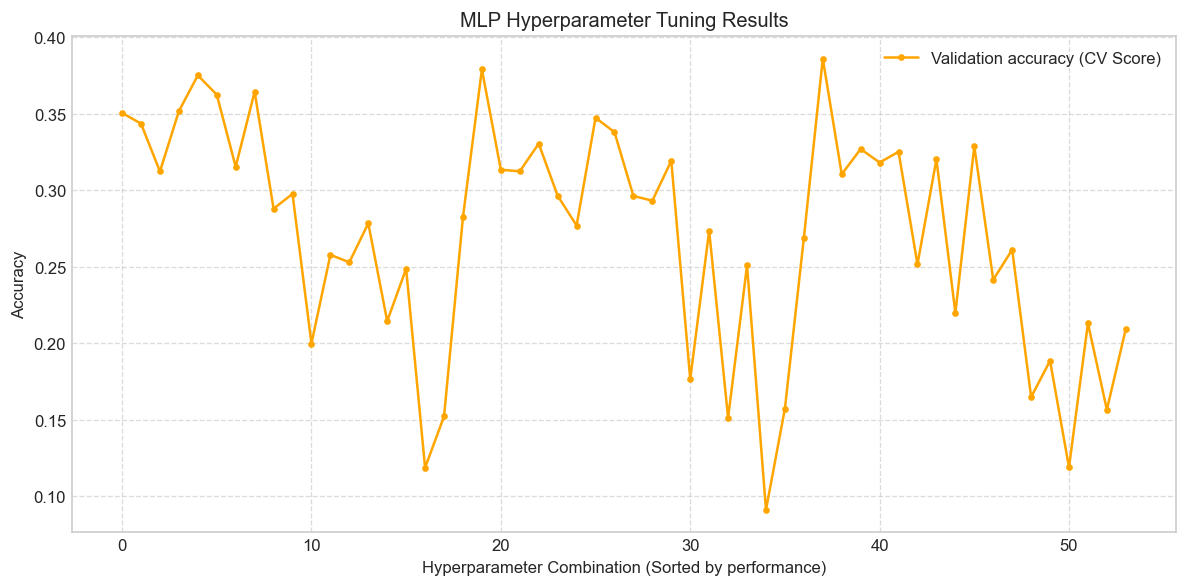

In [15]:
fig, ax = plt.subplots(figsize=(10, 5)) 

ax.plot(
    range(len(mlp_tuning_results_df)),
    mlp_tuning_results_df['mean_test_score'],
    marker='.', 
    linestyle='-',
    color='orange',
    label='Validation accuracy (CV Score)'
)

ax.set_title('MLP Hyperparameter Tuning Results')
ax.set_xlabel('Hyperparameter Combination (Sorted by performance)')
ax.set_ylabel('Accuracy')
ax.legend()

ax.grid(True, linestyle='--', alpha=0.7)

fig.tight_layout()
fig.savefig(output_dir / 'mlp_hyperparameter_tuning.png', bbox_inches='tight', dpi=300)
plt.show()

### Convolutional neural network
In accordance with the assignment requirements, 4 hyperparameters have been selected for tuning.

In [80]:
cnn_param_grid = [
    {'conv_filters': 16, 'dense_units': 64,  'dropout_rate': 0.2, 'learning_rate': 0.001},
    {'conv_filters': 16, 'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001},
    {'conv_filters': 32, 'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001},
    {'conv_filters': 32, 'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.001},
    {'conv_filters': 32, 'dense_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0005},
]

cnn_tuning_results = []

for params in cnn_param_grid:
    print('Training CNN with:', params)

    keras.backend.clear_session()
    cnn_model = build_cnn_model(**params)

    start_time = time.time()

    cnn_history = cnn_model.fit(
        X_train_img,
        y_train_split,
        validation_data=(X_val_img, y_val),
        epochs=10,
        batch_size=128,
        verbose=0
    )

    runtime = time.time() - start_time

    train_accuracy = cnn_history.history['accuracy'][-1]
    val_accuracy = cnn_history.history['val_accuracy'][-1]
    train_loss = cnn_history.history['loss'][-1]
    val_loss = cnn_history.history['val_loss'][-1]

    cnn_tuning_results.append({
        'conv_filters': params['conv_filters'],
        'dense_units': params['dense_units'],
        'dropout_rate': params['dropout_rate'],
        'learning_rate': params['learning_rate'],
        'train_accuracy': train_accuracy,
        'val_accuracy': val_accuracy,
        'train_loss': train_loss,
        'val_loss': val_loss,
        'runtime_seconds': runtime
    })

cnn_tuning_results_df = pd.DataFrame(cnn_tuning_results)
cnn_tuning_results_df

Training CNN with: {'conv_filters': 16, 'dense_units': 64, 'dropout_rate': 0.2, 'learning_rate': 0.001}


W0000 00:00:1777903693.146046    7131 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777903693.165702    7131 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777903693.176053    7131 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777903693.176252    7131 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777903693.177191    7131 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777903693.182757    7131 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777903693.185448    7131 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777903693.185694    7131 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777903693.187871    7131 gp

Training CNN with: {'conv_filters': 16, 'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001}


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Training CNN with: {'conv_filters': 32, 'dense_units': 128, 'dropout_rate': 0.3, 'learning_rate': 0.001}


...

Training CNN with: {'conv_filters': 32, 'dense_units': 128, 'dropout_rate': 0.5, 'learning_rate': 0.001}


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Training CNN with: {'conv_filters': 32, 'dense_units': 256, 'dropout_rate': 0.3, 'learning_rate': 0.0005}


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

,conv_filters,dense_units,dropout_rate,learning_rate,train_accuracy,val_accuracy,train_loss,val_loss,runtime_seconds
0,16,64,0.2,0.0010,0.689492,0.730313,0.855876,0.749543,10.387955
1,16,128,0.3,0.0010,0.726562,0.746406,0.759959,0.705705,8.480582
2,32,128,0.3,0.0010,0.755508,0.770938,0.673620,0.630328,11.350729
3,32,128,0.5,0.0010,0.719375,0.746094,0.780189,0.710298,8.047198
4,32,256,0.3,0.0005,0.767305,0.782969,0.648683,0.599927,8.564024


Then select the optimal parameters and save the results.

In [81]:
best_cnn_row = cnn_tuning_results_df.loc[cnn_tuning_results_df['val_accuracy'].idxmax()]
best_cnn_params = {
    'conv_filters': int(best_cnn_row['conv_filters']),
    'dense_units': int(best_cnn_row['dense_units']),
    'dropout_rate': float(best_cnn_row['dropout_rate']),
    'learning_rate': float(best_cnn_row['learning_rate'])
}

best_cnn_params

{'conv_filters': 32,
 'dense_units': 256,
 'dropout_rate': 0.3,
 'learning_rate': 0.0005}

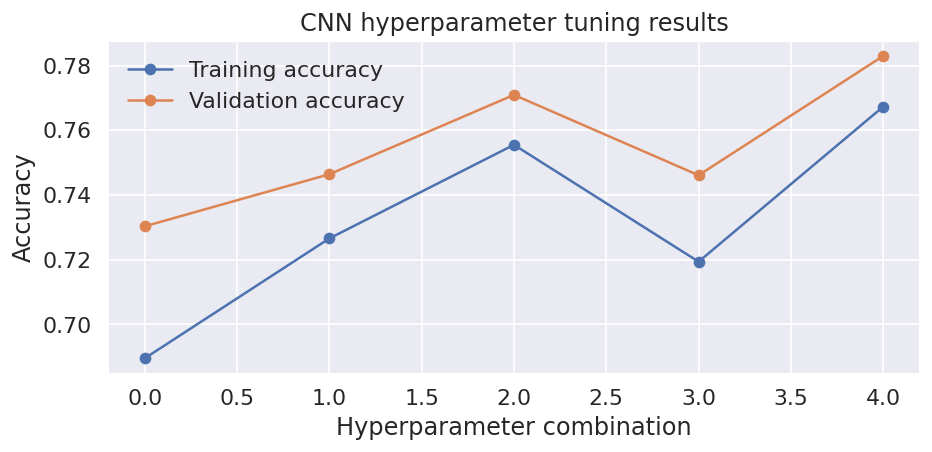

In [82]:
fig, ax = plt.subplots(figsize=(8, 4))

ax.plot(
    range(len(cnn_tuning_results_df)),
    cnn_tuning_results_df['train_accuracy'],
    marker='o',
    label='Training accuracy'
)

ax.plot(
    range(len(cnn_tuning_results_df)),
    cnn_tuning_results_df['val_accuracy'],
    marker='o',
    label='Validation accuracy'
)

ax.set_title('CNN hyperparameter tuning results')
ax.set_xlabel('Hyperparameter combination')
ax.set_ylabel('Accuracy')
ax.legend()

fig.tight_layout()
fig.savefig(output_dir / 'cnn_hyperparameter_tuning.png', bbox_inches='tight')
plt.show()

## 4. Final models
In this section, please ensure to include cells to train each model with its best hyperparmater combination independently of the hyperparameter tuning cells, i.e. don't rely on the hyperparameter tuning cells having been run.

### Logistic Regression (Algorithm of choice from first six weeks of course)

In [99]:
# use best hyperparameters from tuning
try:
    lr_final_params = best_lr_params
    print(f"Using best params from tuning: {lr_final_params}")
except NameError:
    lr_final_params = {'C': 0.0001}
    print(f"Tuning results not found, using fallback: {lr_final_params}")

final_lr_model = build_logistic_regression(**lr_final_params)

# use GPU acceleration for final training, fallback to CPU if not available
try:
    import cupy as cp
    X_train_full_gpu = cp.asarray(X_train_full_flat_scaled)
    y_train_gpu = cp.asarray(y_train)
    X_test_full_gpu = cp.asarray(X_test_full_flat_scaled)
    use_gpu_final = True
except:
    X_train_full_gpu = X_train_full_flat_scaled
    y_train_gpu = y_train
    X_test_full_gpu = X_test_full_flat_scaled
    use_gpu_final = False

fit_start = time.perf_counter()
final_lr_model.fit(X_train_full_gpu, y_train_gpu)
lr_fit_time = time.perf_counter() - fit_start

predict_start = time.perf_counter()
lr_test_pred = final_lr_model.predict(X_test_full_gpu)
if use_gpu_final:
    lr_test_pred = cp.asnumpy(lr_test_pred)
lr_predict_time = time.perf_counter() - predict_start

lr_test_metrics = evaluate_predictions(y_test, lr_test_pred)
lr_final_summary = {
    'model': 'Logistic regression',
    'best_hyperparameters': f"C={lr_final_params['C']}",
    'params': int(final_lr_model.coef_.size + final_lr_model.intercept_.size),
    **lr_test_metrics,
    'fit_time_sec': lr_fit_time,
    'predict_time_sec': lr_predict_time,
}

print('Final logistic regression test results:')
print(lr_final_summary)

Using best params from tuning: {'C': 0.0001}
Final logistic regression test results:
{'model': 'Logistic regression', 'best_hyperparameters': 'C=0.0001', 'params': 21177, 'accuracy': 0.5245, 'macro_f1': 0.4654814056489196, 'weighted_f1': 0.4817717100397955, 'fit_time_sec': 0.8543990799953463, 'predict_time_sec': 0.0026021480007329956}


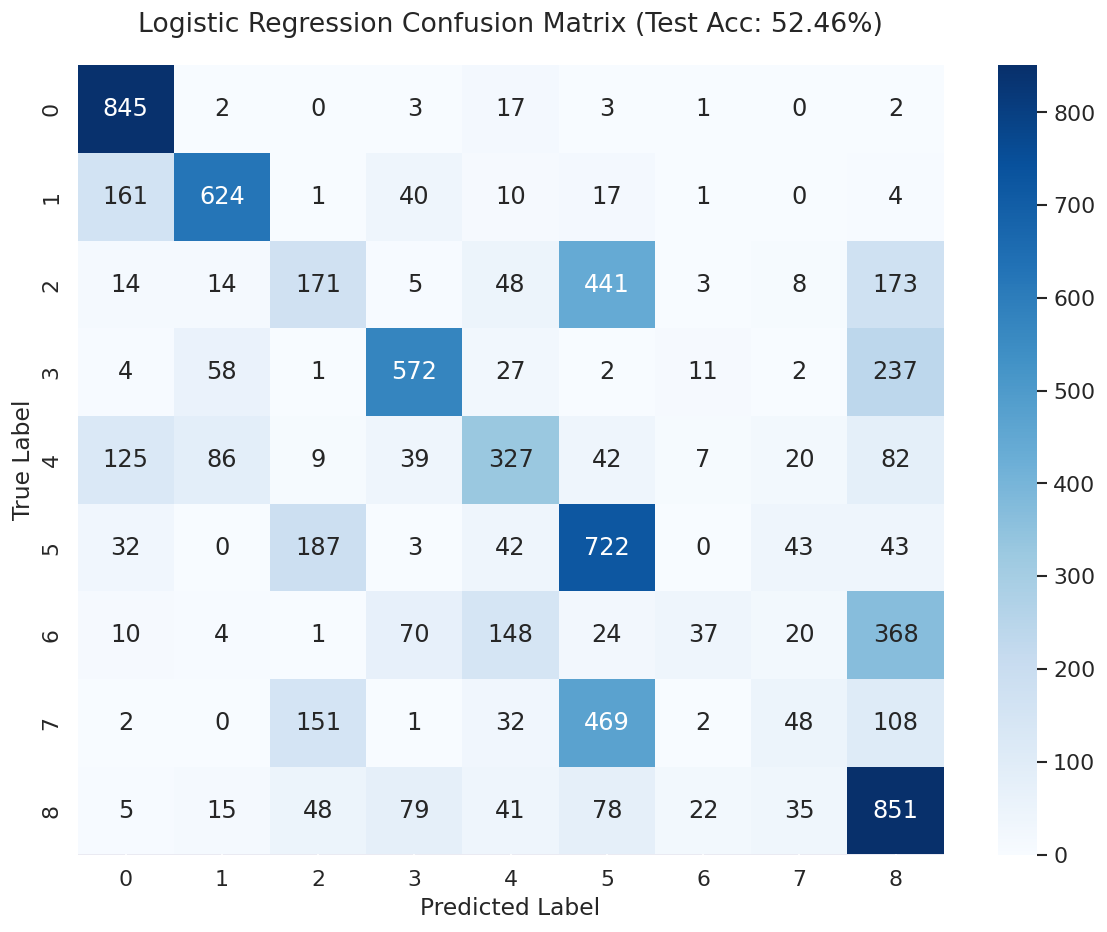

In [84]:
# Confusion matrix
cm = confusion_matrix(y_test, lr_test_pred)

plt.figure(figsize=(10, 8))
sns.set_theme(font_scale=1.2)

# Drawing a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))

plt.title(f'Logistic Regression Confusion Matrix (Test Acc: {lr_test_metrics["accuracy"]:.2%})', pad=20, fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()

# 
plt.savefig(output_dir / 'log_reg_confusion_matrix.png', dpi=300)
plt.show()

### Fully connected neural network

In [16]:
best_mlp_model = grid_search_cv.best_estimator_

# Test Set Evaluation
y_pred_mlp = best_mlp_model.predict(X_test_flat)

test_accuracy = accuracy_score(y_test, y_pred_mlp)
print(f"\n Accuracy of MLP model on test set: {test_accuracy:.4f}")


# Print Categorized Report
print("\n--- (Classification Report) ---")
print(classification_report(y_test, y_pred_mlp, digits=4, zero_division=0))


 Accuracy of MLP model on test set: 0.3315

--- (Classification Report) ---
              precision    recall  f1-score   support

           0     0.6868    0.9748    0.8059       873
           1     0.5665    0.2086    0.3049       858
           2     0.3311    0.1676    0.2226       877
           3     0.0000    0.0000    0.0000       914
           4     0.5796    0.1777    0.2721       737
           5     0.0000    0.0000    0.0000      1072
           6     0.2057    0.2771    0.2361       682
           7     0.4056    0.0898    0.1470       813
           8     0.2314    0.9216    0.3699      1174

    accuracy                         0.3315      8000
   macro avg     0.3341    0.3130    0.2621      8000
weighted avg     0.3181    0.3315    0.2595      8000



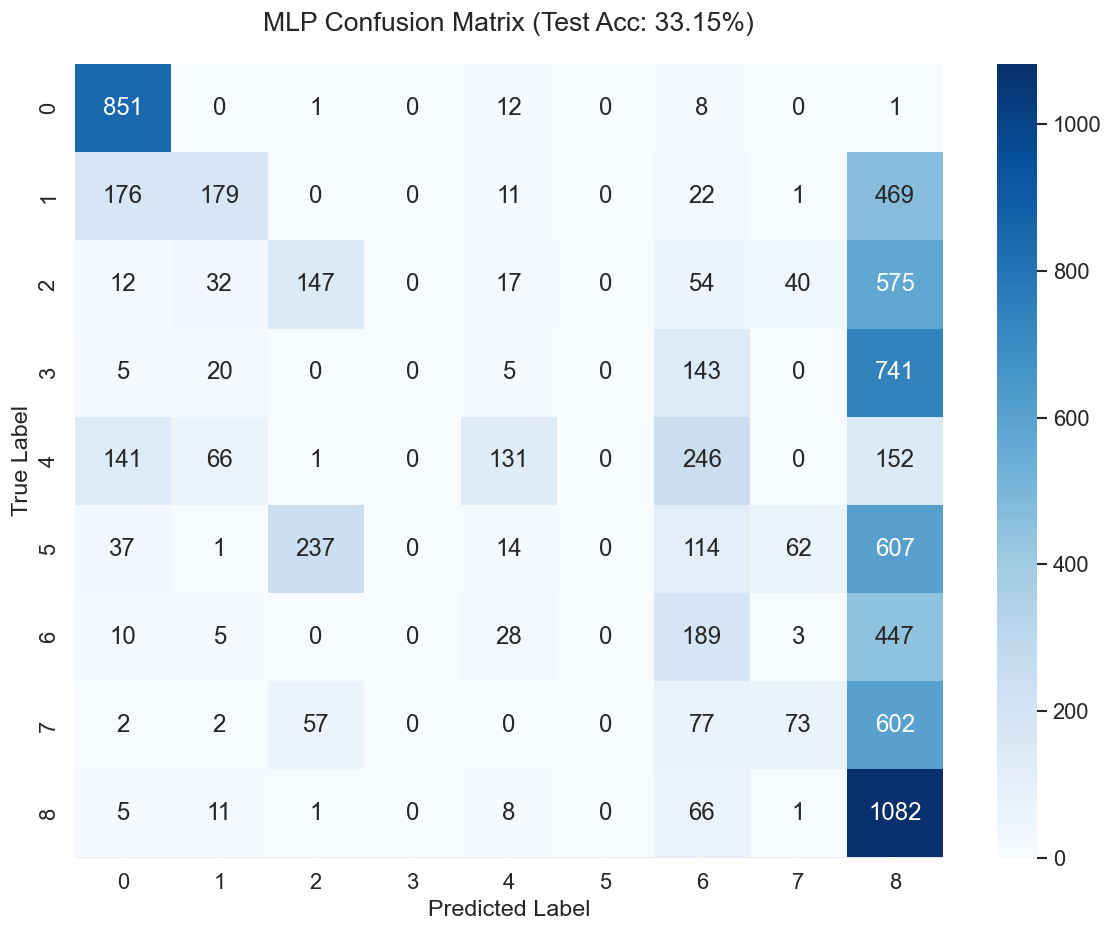

In [17]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_mlp)


plt.figure(figsize=(10, 8))
sns.set_theme(font_scale=1.2)

# Drawing a heatmap
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=np.unique(y_test), 
            yticklabels=np.unique(y_test))

plt.title(f'MLP Confusion Matrix (Test Acc: {test_accuracy:.2%})', pad=20, fontsize=16)
plt.ylabel('True Label', fontsize=14)
plt.xlabel('Predicted Label', fontsize=14)
plt.tight_layout()

# 
plt.savefig(output_dir / 'mlp_confusion_matrix.png', dpi=300)
plt.show()

### Convolutional neural network

In [85]:
keras.backend.clear_session()

final_cnn_model = build_cnn_model(**best_cnn_params)

start_time = time.time()

final_cnn_history = final_cnn_model.fit(
    X_train_img,
    y_train_split,
    validation_data=(X_val_img, y_val),
    epochs=10,
    batch_size=128,
    verbose=1
)

final_cnn_runtime = time.time() - start_time

Epoch 1/10


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

 50/200 [======>.......................] - ETA: 0s - loss: 2.0043 - accuracy: 0.2423

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


200/200 [==============================] - 2s 5ms/step - loss: 1.6375 - accuracy: 0.3834 - val_loss: 1.2259 - val_accuracy: 0.5536
Epoch 2/10
200/200 [==============================] - 1s 4ms/step - loss: 1.1677 - accuracy: 0.5634 - val_loss: 1.0286 - val_accuracy: 0.5956
Epoch 3/10
200/200 [==============================] - 1s 4ms/step - loss: 0.9806 - accuracy: 0.6373 - val_loss: 0.8850 - val_accuracy: 0.6914
Epoch 4/10
200/200 [==============================] - 1s 4ms/step - loss: 0.8725 - accuracy: 0.6818 - val_loss: 0.8007 - val_accuracy: 0.6983
Epoch 5/10
200/200 [==============================] - 1s 4ms/step - loss: 0.8121 - accuracy: 0.6987 - val_loss: 0.7341 - val_accuracy: 0.7333
Epoch 6/10
200/200 [==============================] - 1s 4ms/step - loss: 0.7617 - accuracy: 0.7228 - val_loss: 0.6941 - val_accuracy: 0.7433
Epoch 7/10
200/200 [==============================] - 1s 4ms/step - loss: 0.7295 - accuracy: 0.7334 - val_loss: 0.7068 - val_accuracy: 0.7470
Epoch 8/10
200/20

In [89]:
# Test Set Evaluation
cnn_test_loss, cnn_test_accuracy = final_cnn_model.evaluate(
    X_test_norm,
    y_test,
    verbose=0
)

cnn_test_probabilities = final_cnn_model.predict(X_test_norm)
cnn_test_predictions = np.argmax(cnn_test_probabilities, axis=1)

print(f'CNN test accuracy: {cnn_test_accuracy:.4f}')
print(f'CNN test loss: {cnn_test_loss:.4f}')
print(f'CNN final training runtime: {final_cnn_runtime:.2f} seconds')

W0000 00:00:1777904042.933923    7130 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777904042.934321    7130 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777904042.934404    7130 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777904042.934762    7130 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777904042.935064    7130 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777904042.935187    7130 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777904042.935328    7130 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777904042.935543    7130 gpu_timer.cc:114] Skipping the delay kernel, measurement accuracy will be reduced
W0000 00:00:1777904042.935674    7130 gp

250/250 [==============================] - 0s 2ms/step
CNN test accuracy: 0.7673
CNN test loss: 0.6355
CNN final training runtime: 9.25 seconds


In [90]:
# Print Categorized Report
print(classification_report(y_test, cnn_test_predictions, zero_division=0))

              precision    recall  f1-score   support

           0       0.92      0.95      0.93       873
           1       0.97      0.93      0.95       858
           2       0.66      0.50      0.57       877
           3       0.90      0.97      0.93       914
           4       0.68      0.84      0.75       737
           5       0.84      0.65      0.73      1072
           6       0.63      0.58      0.60       682
           7       0.58      0.54      0.56       813
           8       0.69      0.89      0.78      1174

    accuracy                           0.77      8000
   macro avg       0.76      0.76      0.76      8000
weighted avg       0.77      0.77      0.76      8000



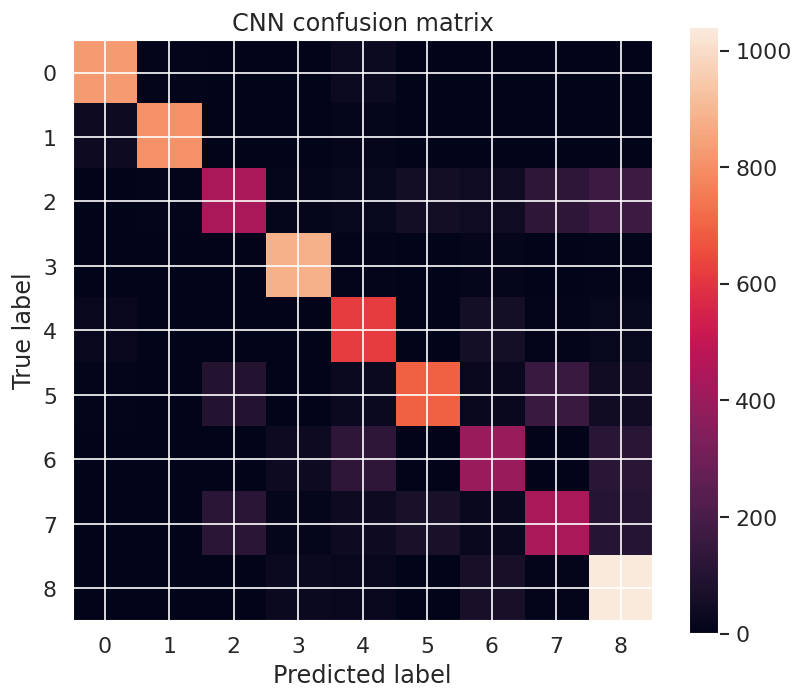

In [91]:
# Confusion matrix
cnn_confusion_matrix = confusion_matrix(y_test, cnn_test_predictions)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(cnn_confusion_matrix)

ax.set_title('CNN confusion matrix')
ax.set_xlabel('Predicted label')
ax.set_ylabel('True label')
ax.set_xticks(range(num_classes))
ax.set_yticks(range(num_classes))

fig.colorbar(im, ax=ax)
fig.tight_layout()
fig.savefig(output_dir / 'cnn_confusion_matrix.png', bbox_inches='tight')
plt.show()

## 5. AI Acknowledgement
Include acknowledgement of AI usage here. 
